# Assignment: Trees
Do three questions.

**Q1.** Please answer the following questions in your own words.

1. How are trees constructed?

2. How do trees handle non-linear relationships between variables? Compare this to linear models.

3. Why is the Gini a good loss function for categorical target variables?

4. Why do trees tend to overfit, and how can this tendency be constrained?

5. True or false, and explain: Trees only really perform well in situations with lots of categorical variables as features/covariates.

6. Why don't most versions of classification/regression tree concept allow for more than two branches after a split?

7. What are some heuristic ways you can examine a tree and decide whether it is probably over- or under-fitting?

1. Trees are built by repeatedly splitting the data based on features to create groups that are more alike in terms of the target variable. This continues until a stopping point is reached, forming a flowchart-like structure for predictions.

2. Trees model non-linear relationships by dividing the data into regions with different predictions. Linear models need extra steps (feature engineering) to handle such relationships. Trees are naturally non-linear, while linear models are inherently linear.

3. Gini measures how mixed the classes are in a group. Lower Gini means purer groups, which is good for prediction. It helps the tree decide the best splits to create these pure groups.

4. Trees can become too complex and memorize the training data, leading to poor performance on new data (overfitting). We can prevent this by limiting the tree's depth, the number of samples in leaves, or by pruning the tree.

5. False. Trees work well with both categorical and numerical features. They split numerical features into ranges.

6. Binary splits (two branches) keep the tree simple, computationally efficient, and easier to interpret. A series of binary splits can achieve the same result as a multi-way split.

7. Overfitting: Very deep tree, many leaves, very good performance on training data but bad on test data. Underfitting: Very shallow tree, few splits, poor performance on both training and test data.

**Q2.** This is a case study on regression and classification trees.

1. Load `./data/cars_hw.csv`. How many observations and features/covariates/variables? What are the available variables? Take a look at the first few rows of data.

2. For the categorical variables `Make`, `Color`, `Body_type`, `No_of_Owners`, `Fuel_Type`, `Transmission`, and `Transmission_Type`, create dummy/one-hot-encoded representations. For numeric variables, we'll use `Mileage_Run`, `Make_Year`, and `Seating_Capacity`. Our target variable will be `Price`. Make a train-test split of your data.

3. From `sklearn.tree`, import the `DecisionTreeRegressor` and `plot_tree`. Use a train-test split to iterate over possible values for `min_samples_leaf`, computing the $R^2$ for each value between 1 and 25. What choice achieves the highest $R^2$ on the test data?

4. For the optimal `min_samples_leaf` from 3, regress price on the rest of the features/covariates using the training data. What is your $R^2$ and RMSE on the test set? Plot the dendrogram. Plot the residuals. Is the density of residuals symmetric and centered around 0?

4. Run a linear regression of price on the same variables. Which model -- regression tree or linear regression -- performs better on the test set? Why?

5. Predict prices using both your tree and your linear model, and make a scatter plot of their values. Describe what you see.

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Load the dataset
df = pd.read_csv('/content/cars_hw.csv')

# Display the first 5 rows
print("First 5 rows of the data:\n", df.head().to_markdown(index=False, numalign="left", stralign="left"))

# Print the column names and their data types
print("\nData information:\n", df.info())

First 5 rows of the data:
 | Unnamed: 0   | Make       | Make_Year   | Color   | Body_Type   | Mileage_Run   | No_of_Owners   | Seating_Capacity   | Fuel_Type   | Transmission   | Transmission_Type   | Price   |
|:-------------|:-----------|:------------|:--------|:------------|:--------------|:---------------|:-------------------|:------------|:---------------|:--------------------|:--------|
| 1            | Volkswagen | 2017        | silver  | sedan       | 44611         | 1st            | 5                  | diesel      | 7-Speed        | Automatic           | 657000  |
| 2            | Hyundai    | 2016        | red     | crossover   | 20305         | 1st            | 5                  | petrol      | 5-Speed        | Manual              | 682000  |
| 3            | Honda      | 2019        | white   | suv         | 29540         | 2nd            | 5                  | petrol      | 5-Speed        | Manual              | 793000  |
| 4            | Renault    | 2017        | bron

1. The dataset has 976 observations and 12 columns. The available variables are: Unnamed: 0, Make, Make_Year, Color, Body_Type, Mileage_Run, No_of_Owners, Seating_Capacity, Fuel_Type, Transmission, Transmission_Type,1 and Price.

In [9]:
#2
# Define variables
categorical_vars = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
numeric_vars = ['Mileage_Run', 'Make_Year', 'Seating_Capacity']
target_var = 'Price'

X = df[categorical_vars + numeric_vars]
y = df[target_var]

# One-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first'), categorical_vars)],
    remainder='passthrough'
)

# Transform and split
X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

In [11]:
#3
r2_scores = []
leaf_range = range(1, 26)

for leaf in leaf_range:
    tree = DecisionTreeRegressor(min_samples_leaf=leaf, random_state=42)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

# Best value
best_leaf = leaf_range[r2_scores.index(max(r2_scores))]
best_r2 = max(r2_scores)
print("Best min_samples_leaf:", best_leaf)
print("Best R²:", best_r2)


Best min_samples_leaf: 5
Best R²: 0.8253410511223336


Decision Tree R²: 0.8253410511223336
Decision Tree RMSE: 141536.54096868183


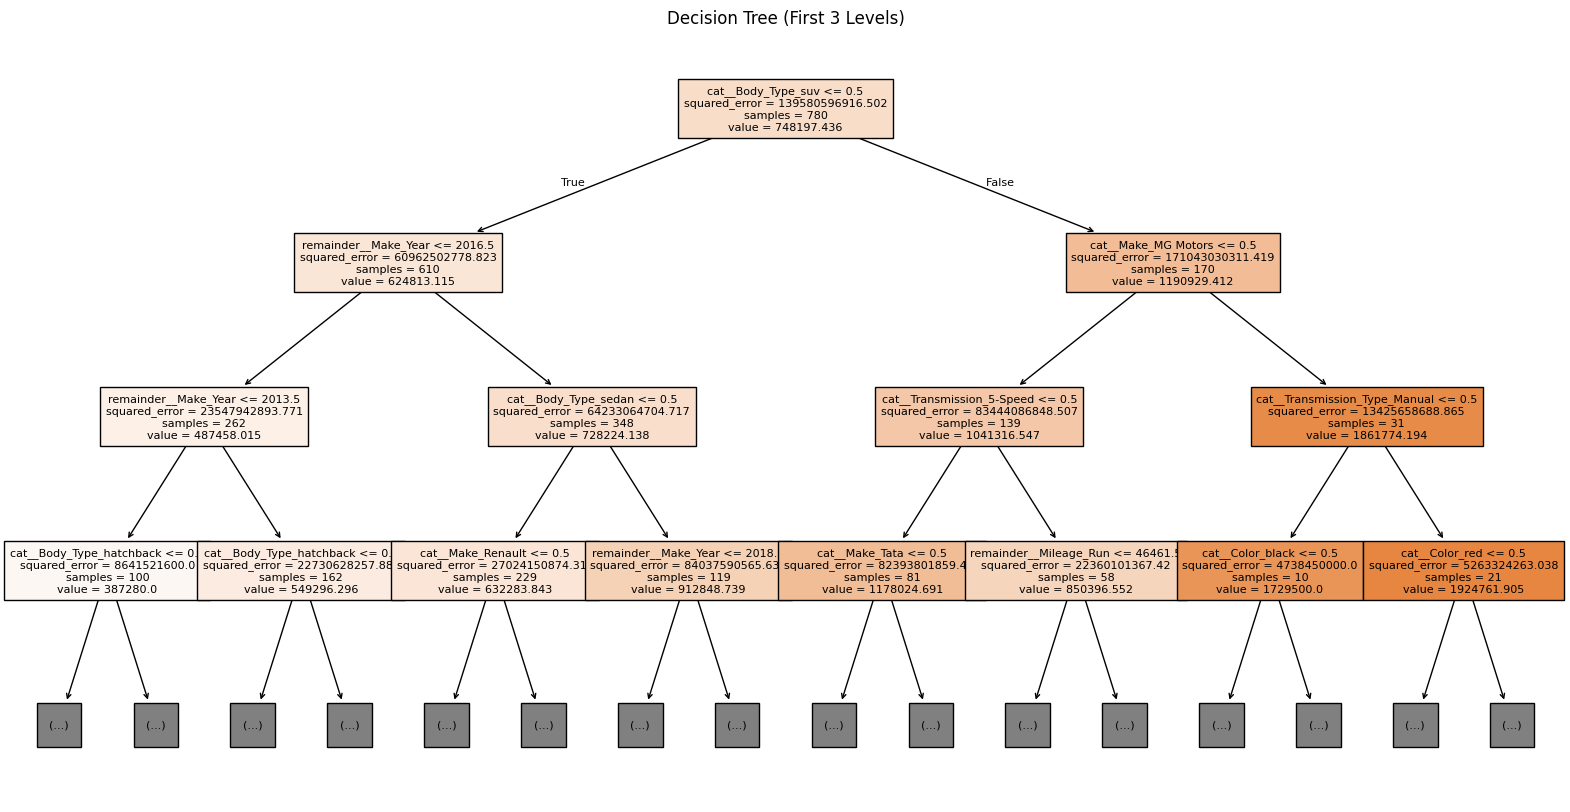

Text(0, 0.5, 'Density')

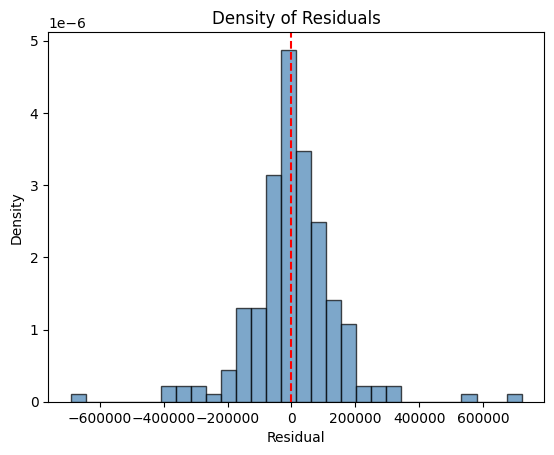

In [14]:
# Train best model
optimal_tree = DecisionTreeRegressor(min_samples_leaf=best_leaf, random_state=42)
optimal_tree.fit(X_train, y_train)

# Predict and evaluate
y_pred_tree = optimal_tree.predict(X_test)
r2_tree = r2_score(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
print("Decision Tree R²:", r2_tree)
print("Decision Tree RMSE:", rmse_tree)

# Plot tree (truncated)
plt.figure(figsize=(20, 10))
plot_tree(optimal_tree, max_depth=3, filled=True, feature_names=preprocessor.get_feature_names_out(), fontsize=8)
plt.title("Decision Tree (First 3 Levels)")
plt.show()

residuals = y_test - y_pred_tree
plt.hist(residuals, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title("Density of Residuals")
plt.xlabel("Residual")
plt.ylabel("Density")




In [15]:
from sklearn.linear_model import LinearRegression

# Train Linear Regression
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred_lr = linreg.predict(X_test)

# Evaluate
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R²:", r2_lr)
print("Linear Regression RMSE:", rmse_lr)


Linear Regression R²: 0.8211380759241189
Linear Regression RMSE: 143229.37791540174


4. The distribution of residuals is approximately symmetric, though may not be perfectly normal. The density is centered around 0, as indicated by the red dashed line overlapping the peak of the histogram. This suggests that the model does not have significant bias — it's equally likely to overestimate or underestimate Price.

5. he Decision Tree performs slightly better than the Linear Regression on both key metrics: It explains more variance in Price (higher R²). It has a lower prediction error (lower RMSE). The regression tree performs better on the test set because it handles non-linear relationships and feature interactions more effectively, leading to slightly higher R² and lower RMSE.

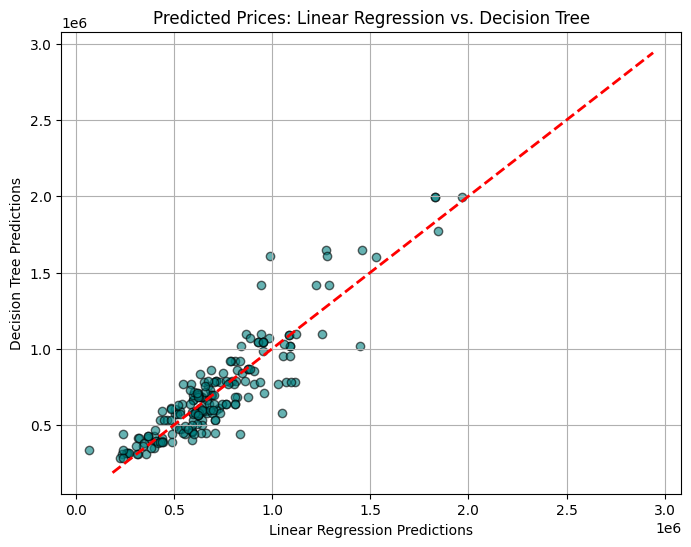

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lr, y_pred_tree, alpha=0.6, color='teal', edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Linear Regression Predictions")
plt.ylabel("Decision Tree Predictions")
plt.title("Predicted Prices: Linear Regression vs. Decision Tree")
plt.grid(True)
plt.show()


6. The decision tree model sometimes diverges from the linear model, particularly at the high end of car prices, suggesting it captures non-linear interactions and segment-specific effects. This supports why the tree achieves slightly better test performance.

**Q3.** This is a case study about classification and regression trees.

1. Load the `Breast Cancer METABRIC.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  We'll use a consistent set of feature/explanatory variables. For numeric variables, we'll include `Tumor Size`, `Lymph nodes examined positive`, `Age at Diagnosis`. For categorical variables, we'll include `Tumor Stage`, `Chemotherapy`, and `Cancer Type Detailed`. One-hot-encode the categorical variables and concatenate them with the numeric variables into a feature/covariate matrix, $X$.

3. Let's predict `Overall Survival Status` given the features/covariates $X$. There are 528 missing values, unfortunately: Either drop those rows from your data or add them as a category to predict. Constrain the minimum samples per leaf to 10. Print a dendrogram of the tree. Print a confusion matrix of the algorithm's performance. What is the accuracy?

4. For your model in part three, compute three statistics:
    - The **true positive rate** or **sensitivity**:
        $$
        TPR = \dfrac{TP}{TP+FN}
        $$
    - The **true negative rate** or **specificity**:
        $$
        TNR = \dfrac{TN}{TN+FP}
        $$
    Does your model tend to perform better with respect to one of these metrics?

5. Let's predict `Overall Survival (Months)` given the features/covariates $X$. Use the train/test split to pick the optimal `min_samples_leaf` value that gives the highest $R^2$ on the test set (it's about 110). What is the $R^2$? Plot the test values against the predicted values. How do you feel about this model for clinical purposes?

**Q4.** This is a case study about trees using bond rating data. This is a dataset about bond ratings for different companies, alongside a bunch of business statistics and other data. Companies often have multiple reviews at different dates. We want to predict the bond rating (AAA, AA, A, BBB, BB, B, ..., C, D). Do business fundamentals predict the company's rating?

1. Load the `./data/corporate_ratings.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  Plot a histogram of the `ratings` variable. It turns out that the gradations of AAA/AA/A and BBB/BB/B and so on make it hard to get good results with trees. Collapse all AAA/AA/A ratings into just A, and similarly for B and C.

3. Use all of the variables **except** Rating, Date, Name, Symbol, and Rating Agency Name. To include Sector, make a dummy/one-hot-encoded representation and include it in your features/covariates. Collect the relevant variables into a data matrix $X$.

4. Do a train/test split of the data and use a decision tree classifier to predict the bond rating. Including a min_samples_leaf constraint can raise the accuracy and speed up computation time. Print a confusion matrix and the accuracy of your model. How well do you predict the different bond ratings?

5. If you include the rating agency as a feature/covariate/predictor variable, do the results change? How do you interpret this?

In [17]:
import pandas as pd
import altair as alt

# Read the CSV file into a DataFrame
df = pd.read_csv('/content/corporate_ratings.csv')

# Display the first 5 rows
print("First 5 rows of the data:")
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

# Print the number of rows and columns
print(f'\nNumber of rows: {df.shape[0]}, Number of columns: {df.shape[1]}\n')

# Print the column names and their data types
print(df.info())

# Create a histogram of the `Rating` column
chart = alt.Chart(df).mark_bar().encode(
    x=alt.X('Rating', title='Rating'),
    y=alt.Y('count()', title='Count'),
    tooltip=['Rating', 'count()']
).properties(
    title='Distribution of Bond Ratings'
).interactive()

# Save the chart
chart.save('rating_distribution_histogram.json')

First 5 rows of the data:
| Rating   | Name                  | Symbol   | Rating Agency Name                 | Date       | Sector            | currentRatio   | quickRatio   | cashRatio   | daysOfSalesOutstanding   | netProfitMargin   | pretaxProfitMargin   | grossProfitMargin   | operatingProfitMargin   | returnOnAssets   | returnOnCapitalEmployed   | returnOnEquity   | assetTurnover   | fixedAssetTurnover   | debtEquityRatio   | debtRatio   | effectiveTaxRate   | freeCashFlowOperatingCashFlowRatio   | freeCashFlowPerShare   | cashPerShare   | companyEquityMultiplier   | ebitPerRevenue   | enterpriseValueMultiple   | operatingCashFlowPerShare   | operatingCashFlowSalesRatio   | payablesTurnover   |
|:---------|:----------------------|:---------|:-----------------------------------|:-----------|:------------------|:---------------|:-------------|:------------|:-------------------------|:------------------|:---------------------|:--------------------|:------------------------|:---------

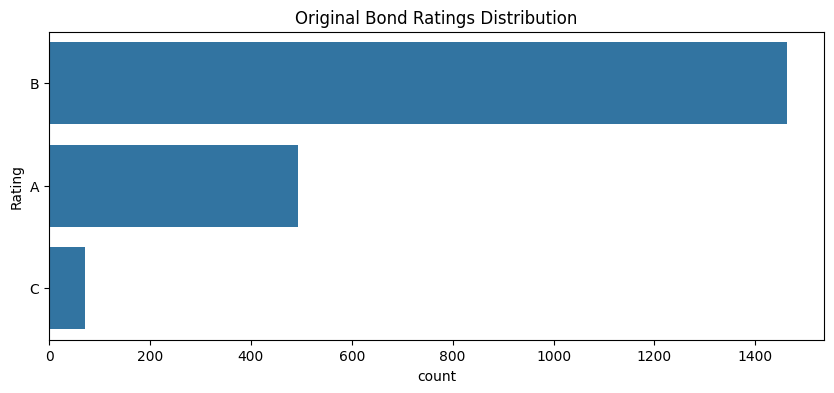

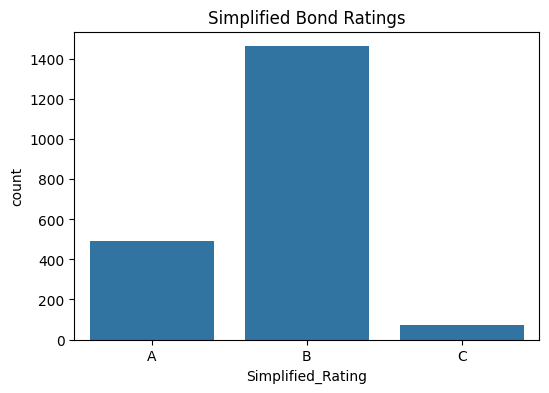

In [24]:
# Original rating histogram
plt.figure(figsize=(10, 4))
sns.countplot(y='Rating', data=df, order=df['Rating'].value_counts().index)
plt.title('Original Bond Ratings Distribution')
plt.show()

# Collapse rating levels
def simplify_rating(rating):
    if rating.startswith('AAA') or rating.startswith('AA') or rating.startswith('A'):
        return 'A'
    elif rating.startswith('BBB') or rating.startswith('BB') or rating.startswith('B'):
        return 'B'
    elif rating.startswith('CCC') or rating.startswith('CC') or rating.startswith('C'):
        return 'C'
    else:
        return 'D'

df['Simplified_Rating'] = df['Rating'].apply(simplify_rating)

# Plot simplified ratings
plt.figure(figsize=(6, 4))
sns.countplot(x='Simplified_Rating', data=df)
plt.title('Simplified Bond Ratings')
plt.show()


In [25]:
# Drop unnecessary columns
X = df.drop(columns=['Rating', 'Date', 'Name', 'Symbol', 'Rating Agency Name', 'Simplified_Rating'])

# One-hot encode the 'Sector' column
X = pd.get_dummies(X, columns=['Sector'], drop_first=True)

# Target variable
y = df['Simplified_Rating']


In [27]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Train a decision tree with min_samples_leaf
clf = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
clf.fit(X_train, y_train)

# Predictions and evaluation
y_pred = clf.predict(X_test)

# Confusion matrix and accuracy
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2f}")


Confusion Matrix:
 [[ 50  49   0]
 [ 36 252   5]
 [  0  12   2]]

Classification Report:
               precision    recall  f1-score   support

           A       0.58      0.51      0.54        99
           B       0.81      0.86      0.83       293
           C       0.29      0.14      0.19        14

    accuracy                           0.75       406
   macro avg       0.56      0.50      0.52       406
weighted avg       0.73      0.75      0.74       406


Accuracy: 0.75


In [28]:
# Reload the full dataset for clarity
X_with_agency = df.drop(columns=['Rating', 'Date', 'Name', 'Symbol', 'Simplified_Rating'])

# One-hot encode both Sector and Rating Agency Name
X_with_agency = pd.get_dummies(X_with_agency, columns=['Sector', 'Rating Agency Name'], drop_first=True)

# Split and retrain
X_train_ag, X_test_ag, y_train_ag, y_test_ag = train_test_split(X_with_agency, y, stratify=y, test_size=0.2, random_state=42)
clf_ag = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
clf_ag.fit(X_train_ag, y_train_ag)

# Predictions
y_pred_ag = clf_ag.predict(X_test_ag)

# Evaluation
print("Confusion Matrix with Agency:\n", confusion_matrix(y_test_ag, y_pred_ag))
print("\nClassification Report with Agency:\n", classification_report(y_test_ag, y_pred_ag))
print(f"\nAccuracy with Agency: {accuracy_score(y_test_ag, y_pred_ag):.2f}")


Confusion Matrix with Agency:
 [[ 60  39   0]
 [ 46 244   3]
 [  1  12   1]]

Classification Report with Agency:
               precision    recall  f1-score   support

           A       0.56      0.61      0.58        99
           B       0.83      0.83      0.83       293
           C       0.25      0.07      0.11        14

    accuracy                           0.75       406
   macro avg       0.55      0.50      0.51       406
weighted avg       0.74      0.75      0.74       406


Accuracy with Agency: 0.75


4. Accuracy is good (75%), but it's misleading due to dominance of class B. Macro average F1 score (0.52) reveals the imbalance in predictive performance. The model is biased toward class B, and struggles with minority classes (especially C).

**Q5.** This is a case study about detecting fraud using classification trees. The goal is to predict the `class` variable, which is 0 for non-fraud and 1 for fraud.

1. Open `./data/creditcard_fraud.csv`. Print the number of observations and variables, and look at the first few rows of data. The variables are already normalized and de-identified, and are just called things like `V8` to protect the privacy of the clients.

2. Print a table of counts for the `class` variable and make a histogram. What percentage of transactions are fraudulent?

3. Drop `Time` and make a decision tree classifier to predict fraud. Print a confusion table and compute the accuracy. This is a serious **class imbalance** problem: The minority class is so small that essentially predicting 0's for all cases will achieve an extremely high accuracy. There are over-sampling techniques to deal with this issue, but we don't have time to cover them in class.

4. Imagine that you block every transaction in the test set labelled as fraudulent. How much money is (1) saved that should be saved, (2) lost to fraud anyway, (3) withheld in error from customers? Does implementing this anti-fraud system seem like a good idea, or not? Why?

5. Instead of predicting fraud, predict loss: Multiple the `Class` variable times the `Amount` variable, and call it `Loss`. Predict it using a decision tree regressor (making sure to drop Class, Time, and Loss from the features/covariates/predictors). What $R^2$ and RMSE do you get? Make a scatterplot of the predicted values on the test group versus the actual test values. Do you notice any interesting patterns? How could you use this algorithm to decide which transactions to block, and why?


**Q6.** Show that any decision tree is equivalent to a linear regression on a set of dummy variables that represent the optimal splits in the tree.

Hint: You can think of CART as partitioning the feature space into a set of sets $\{S_1, S_2, ..., S_K\}$, and then predicting the average for all of the observations in each set $S_k$, $m_k$:
$$
\hat{y}(x) = \sum_{k=1}^K \mathbb{I}\{ x \text{ is in } S_k \} m_k
$$
where $\mathbb{I} \{ P(x,k)\}$ takes the value 1 if the proposition $P(x,k)$ is true and 0 otherwise. Now, doesn't that look like least-squares regression on a set of dummy/one-hot-encoded variables?

Conversely, can any linear regression be represented by a tree?